# SmolLM3 Eval Comparison (Decay vs No-Decay)\n
Set your two run paths below, run all cells, and inspect plots + tables.

In [1]:
from pathlib import Path
import pandas as pd
from plot_eval_comparison import load_run, RunInfo, plot_grouped_bars, plot_deltas, make_summary_table

In [2]:
BASELINE_ROOT = Path("/iopsstor/scratch/cscs/kponkshe/sb-decay/checkpoints/run_decay_dolma/hf/evals/lm_eval/base/0shot/__iopsstor__scratch__cscs__kponkshe__sb-decay__checkpoints__run_decay_dolma__hf/")

CANDIDATE_ROOT = Path("/iopsstor/scratch/cscs/kponkshe/sb-decay/checkpoints/run_stable_dolma/hf/evals/lm_eval/base/0shot/__iopsstor__scratch__cscs__kponkshe__sb-decay__checkpoints__run_stable_dolma__hf/")



In [11]:
baseline_label = 'decay'
candidate_label = 'stable_only'


b = load_run(RunInfo(label=baseline_label, root=BASELINE_ROOT))
c = load_run(RunInfo(label=candidate_label, root=CANDIDATE_ROOT))
m = b[['task','value']].rename(columns={'value': baseline_label}).merge(
    c[['task','value']].rename(columns={'value': candidate_label}), on='task', how='inner'
)
# Drop MMLU/MMLU-Pro subset rows (e.g., mmlu_abstract_algebra, mmlu_pro_*)
subset_mask = m["task"].str.contains(r"^mmlu[_:]|^mmlu_pro[_:]", case=False, regex=True)
m = m.loc[~subset_mask].copy()

# If you also want to drop aggregate rows "mmlu" / "mmlu_pro", use this instead:
# all_mmlu_mask = m["task"].str.contains(r"^mmlu($|[_:])|^mmlu_pro($|[_:])", case=False, regex=True)
# m = m.loc[~all_mmlu_mask].copy()

m["delta"] = m[candidate_label] - m[baseline_label]
m = m.sort_values("task").reset_index(drop=True)

m['delta'] = m[candidate_label] - m[baseline_label]
m = m.sort_values('task').reset_index(drop=True)

m.head()

,task,decay,stable_only,delta
0,arc_challenge,0.506826,0.465017,-0.041809
1,arc_easy,0.764310,0.732744,-0.031566
2,boolq,0.730887,0.724771,-0.006116
3,commonsense_qa,0.493038,0.499590,0.006552
4,hellaswag,0.703446,0.676957,-0.026489


In [12]:
summary = make_summary_table(m[['task', baseline_label, candidate_label, 'delta']])
summary

,num_tasks,baseline_mean,candidate_mean,delta_mean,delta_median,num_improved,num_regressed,num_tied
0,9,0.618869,0.608468,-0.010401,-0.007193,3,6,0


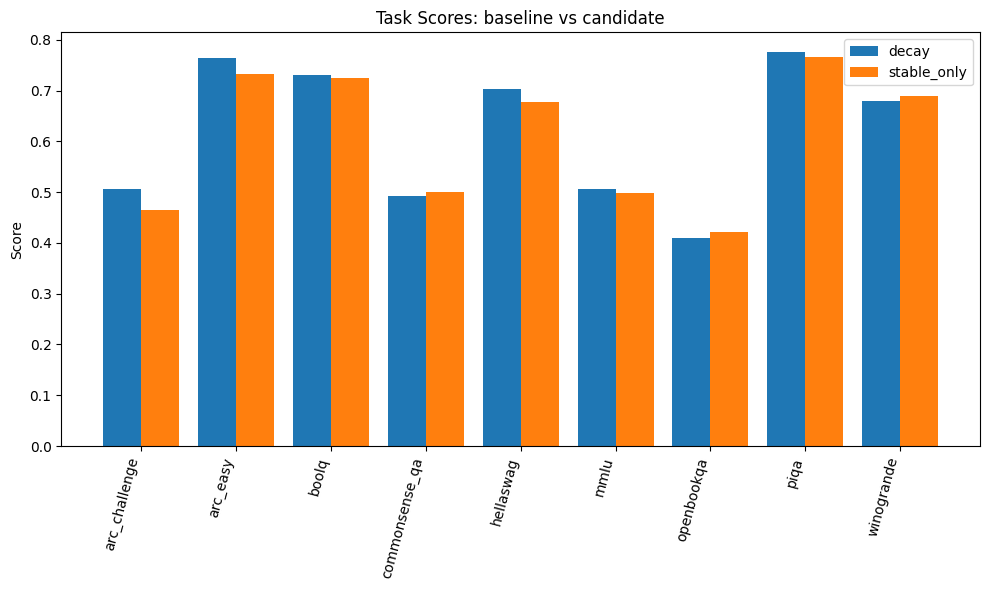

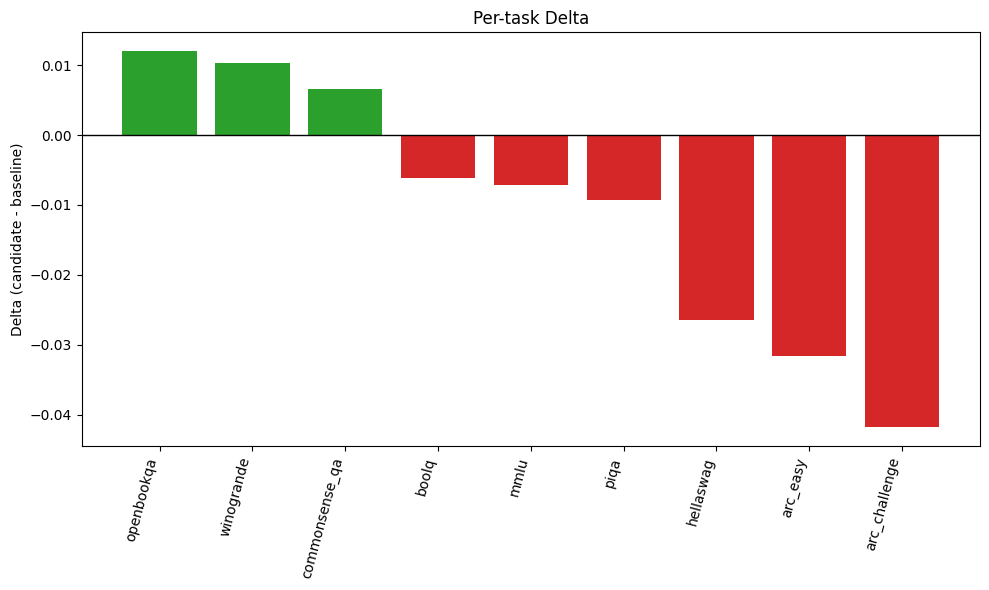

In [13]:
plot_grouped_bars(
    m[['task', baseline_label, candidate_label]],
    None,
    baseline_label,
    candidate_label,
    save=False,
    show=True,
)

plot_deltas(
    m[['task', 'delta']],
    None,
    save=False,
    show=True,
)

